In [ ]:
AMAZON MUSIC CLUSTERING - MINI PROJECT 4

In [ ]:
Step 1: Data pre-processing and data cleaning.

In [1]:
import matplotlib.pyplot as plt
import pandas as pd
import seaborn as sns

# ==============================================================================
# STEP 1: loading the dataset and checking if there is any file path error
# ==============================================================================
# try-except block to safely load the dataset and tell
# if there is a file path configuration error.
try:
    df = pd.read_csv("single_genre_artists.csv")
    print("Dataset successfully loaded!\n")
except FileNotFoundError:
    print(
        "Error: single_genre_artists.csv not found. Check your file path."
    )

# ==============================================================================
# STEP 2: EDA Analysis steps
# ==============================================================================
print("--- Dataset Shape (Rows, Columns) ---")
print(df.shape)

print("\n--- Column Names and Data Types ---")
print(df.info())

print("\n--- First 5 Rows ---")
print(df.head())

print("\n--- Checking for Missing Values ---")
print(df.isnull().sum())

print("\n--- Checking for Duplicate Rows ---")
print(f"Total duplicates: {df.duplicated().sum()}")

# ==============================================================================
# STEP 3: Feature selection, dropping uneccessary columns
# ==============================================================================
columns_to_drop = ["track_name", "name_artists", "track_id"]

df_cleaned = df.drop(columns=columns_to_drop, errors="ignore")

print("\n--- Remaining Columns for Machine Learning ---")
print(df_cleaned.columns.tolist())

Dataset successfully loaded!

--- Dataset Shape (Rows, Columns) ---
(95837, 23)

--- Column Names and Data Types ---
<class 'pandas.DataFrame'>
RangeIndex: 95837 entries, 0 to 95836
Data columns (total 23 columns):
 #   Column              Non-Null Count  Dtype  
---  ------              --------------  -----  
 0   id_songs            95837 non-null  str    
 1   name_song           95837 non-null  str    
 2   popularity_songs    95837 non-null  int64  
 3   duration_ms         95837 non-null  int64  
 4   explicit            95837 non-null  int64  
 5   id_artists          95837 non-null  str    
 6   release_date        95837 non-null  str    
 7   danceability        95837 non-null  float64
 8   energy              95837 non-null  float64
 9   key                 95837 non-null  int64  
 10  loudness            95837 non-null  float64
 11  mode                95837 non-null  int64  
 12  speechiness         95837 non-null  float64
 13  acousticness        95837 non-null  float64
 

In [ ]:
Step 1: converyting the release date column into numerical year for this analysis. 
here for this analysis, the the name_song and id_artists are not converted into integers, 
but release_date is converted into a numeric year because forcing categorical identifiers into integers 
introduces flawed mathematical relationships that will corrupt my K-means results.

In [ ]:
import pandas as pd
from sklearn.cluster import KMeans
from sklearn.preprocessing import StandardScaler

# converting the release date colum into a numerical year form for this analysis using this code after importing all the libraries.
df["release_year"] = pd.to_datetime(df["release_date"], errors="coerce").dt.year
df["release_year"] = df["release_year"].fillna(df["release_year"].median()).astype("int64")

clustering_features = [
    "popularity_songs",
    "duration_ms",
    "explicit",
    "danceability",
    "energy",
    "key",
    "loudness",
    "mode",
    "speechiness",
    "acousticness",
    "release_year",  
]

X = df[clustering_features]
scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)

kmeans = KMeans(n_clusters=4, random_state=42)
df["cluster_labels"] = kmeans.fit_predict(X_scaled)

print(df[["name_song", "id_artists", "cluster_labels"]].head())

          name_song              id_artists  cluster_labels
0           La Java  4AxgXfD7ISvJSTObqm4aIE               0
1          En Douce  4AxgXfD7ISvJSTObqm4aIE               0
2     J'en Ai Marre  4AxgXfD7ISvJSTObqm4aIE               0
3  Ils n'ont pas ca  4AxgXfD7ISvJSTObqm4aIE               0
4         La belote  4AxgXfD7ISvJSTObqm4aIE               0


In [ ]:
Step 2: Visualising the data.

Visualizing distributions for: ['popularity_songs', 'duration_ms', 'explicit', 'danceability', 'energy', 'key', 'loudness', 'mode', 'speechiness', 'acousticness', 'instrumentalness', 'liveness', 'valence', 'tempo', 'time_signature', 'followers', 'popularity_artists']


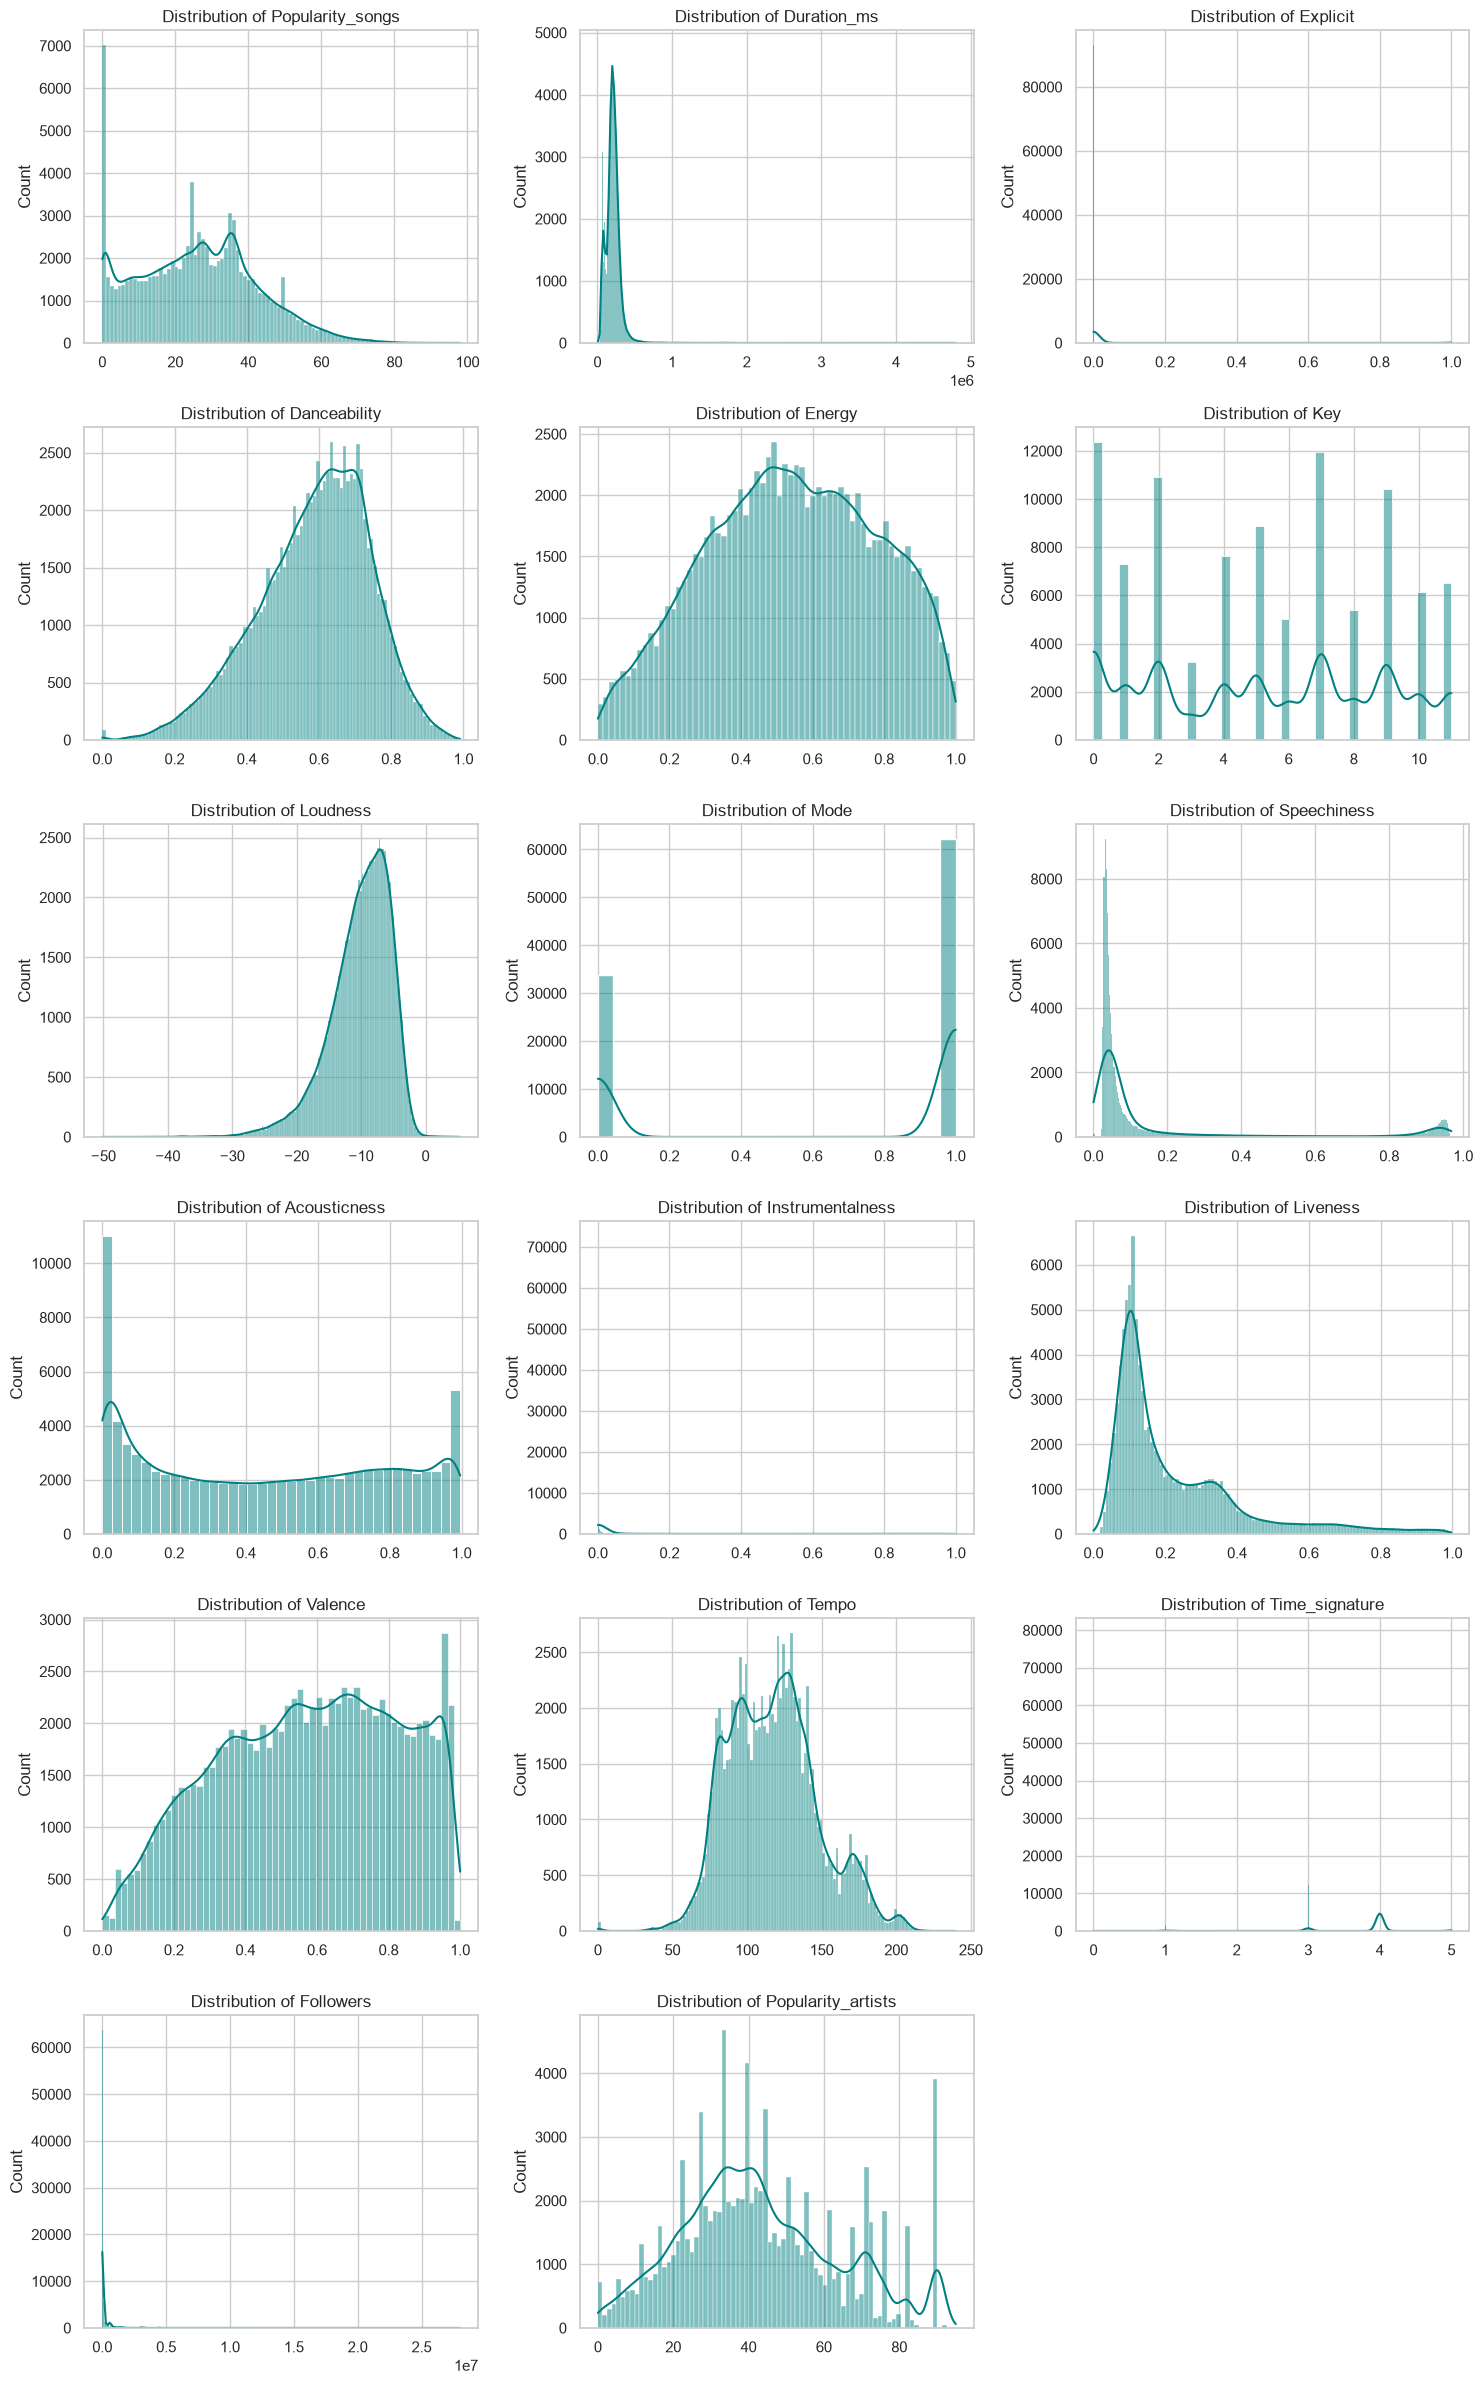

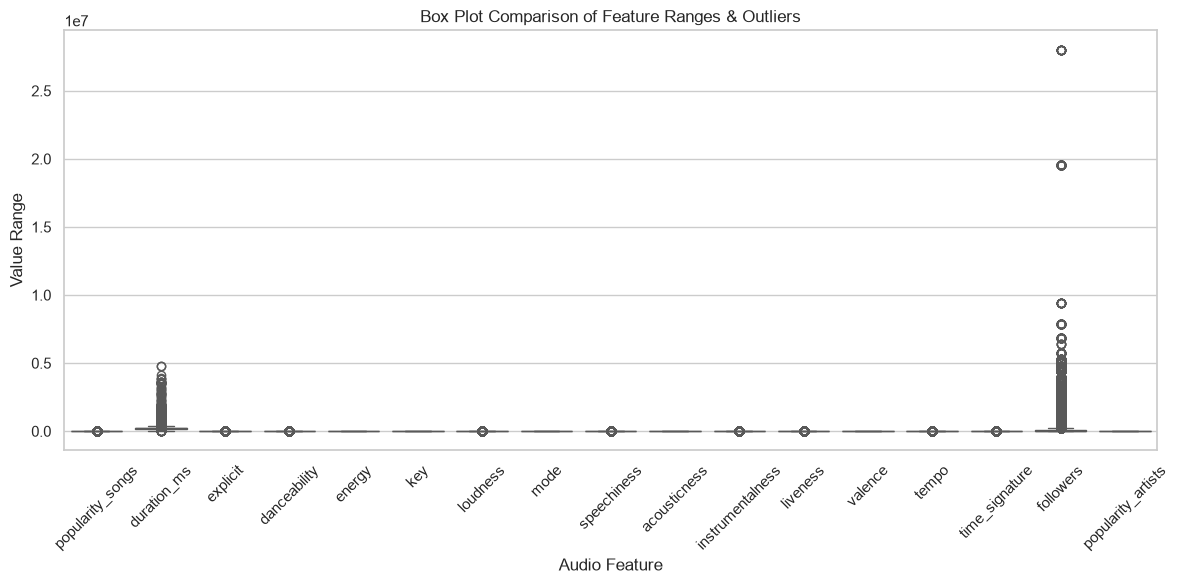

In [50]:
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import seaborn as sns

# ==============================================================================
# STEP 1: isolating all numeric columns for the ML analysis
# ==============================================================================
numerical_features = df_cleaned.select_dtypes(include=[np.number]).columns.tolist()

audio_features = [
    col for col in numerical_features
    if col not in ["cluster", "pca_1", "pca_2"]
]

print(f"Visualizing distributions for: {audio_features}")

sns.set_theme(style="whitegrid")

# ==============================================================================
# STEP 2: Creating a histogram plot for the analysis of the data distributions of all the columns in the dataset
# ==============================================================================

num_plots = len(audio_features)
cols = 3
rows = (num_plots + cols - 1) // cols 

fig, axes = plt.subplots(rows, cols, figsize=(15, rows * 4))
axes = axes.flatten()  

for i, feature in enumerate(audio_features):
    sns.histplot(
        data=df_cleaned, x=feature, kde=True, ax=axes[i], color="teal"
    )
    axes[i].set_title(f"Distribution of {feature.capitalize()}")
    axes[i].set_xlabel("")
    axes[i].set_ylabel("Count")

for j in range(i + 1, len(axes)):
    fig.delaxes(axes[j])

plt.tight_layout()
plt.show()

# ==============================================================================
# STEP 3: Outlier plot to check for outliers in the dataset
# ==============================================================================

plt.figure(figsize=(12, 6))

df_melted = pd.melt(df_cleaned[audio_features])

sns.boxplot(data=df_melted, x="variable", y="value", hue="variable", palette="Set2", legend=False)

plt.title("Box Plot Comparison of Feature Ranges & Outliers")
plt.xticks(rotation=45)
plt.xlabel("Audio Feature")
plt.ylabel("Value Range")

plt.tight_layout()
plt.show()

In [ ]:
Step 3. Treating the outliers with the DBScan method for the duration_ms and followers columns.

In [ ]:
import pandas as pd
from sklearn.cluster import DBSCAN
from sklearn.preprocessing import StandardScaler


file_path = r"C:\Users\pc\Desktop\miniproject4\single_genre_artists.xlsx"
df = pd.read_excel(file_path)

print(f"Original dataset shape: {df.shape}")

# ==============================================================================
# STEP 1: isolating the outlier features to be treated and applying the standard scaler
# ==============================================================================

columns_to_clean = ['duration_ms', 'followers']

scaler = StandardScaler()
scaled_features = scaler.fit_transform(df[columns_to_clean])

# ==============================================================================
# STEP 3: Using the DBSCAN method to treat the outliers.
# ==============================================================================
dbscan = DBSCAN(eps=0.15, min_samples=5)
dbscan_labels = dbscan.fit_predict(scaled_features)
df['is_outlier'] = dbscan_labels == -1

df_cleaned = df[df['is_outlier'] == False].drop(columns=['is_outlier'])

print(f"Detected and removed {sum(dbscan_labels == -1)} outlier rows.")
print(f"Dataset shape after DBSCAN cleaning: {df_cleaned.shape}")

# ==============================================================================
# STEP 5: exporting the cleaned DBSCAN dataset to excel
# ==============================================================================

output_path = r"C:\Users\pc\Desktop\miniproject4\single_genre_artists_dbscan_cleaned.xlsx"
df_cleaned.to_excel(output_path, index=False)
print(f"Success! Cleaned dataset saved to: {output_path}")

Original dataset shape: (95837, 24)
Detected and removed 209 outlier rows.
Dataset shape after DBSCAN cleaning: (95628, 24)
Success! Cleaned dataset saved to: C:\Users\pc\Desktop\miniproject4\single_genre_artists_dbscan_cleaned.xlsx


In [ ]:
Step 3. Normalizing the data. 

In [ ]:
import pandas as pd
from sklearn.preprocessing import StandardScaler


file_path = r"C:\Users\pc\Desktop\miniproject4\single_genre_artists_dbscan_cleaned.xlsx"
df = pd.read_excel(file_path)

# ==============================================================================
# STEP 2: Isolating the features to be normalized. 
# ==============================================================================
audio_features = [
    'danceability', 'energy', 'loudness', 'speechiness', 
    'acousticness', 'instrumentalness', 'liveness', 
    'valence', 'tempo', 'duration_ms'
]

available_features = [col for col in audio_features if col in df.columns]

X_raw = df[available_features]

# ==============================================================================
# STEP 3: Transforming the values into a universal scale (mean=0, variance=1) using StandardScaler. 
# ==============================================================================

scaler = StandardScaler()
X_scaled = scaler.fit_transform(X_raw)



print(f"Feature matrix prepared successfully.")
print(f"Shape of scaled feature matrix: {X_scaled.shape}")
print(f"Features included: {available_features}")
print("Data normalized using StandardScaler.")

Feature matrix prepared successfully.
Shape of scaled feature matrix: (95628, 10)
Features included: ['danceability', 'energy', 'loudness', 'speechiness', 'acousticness', 'instrumentalness', 'liveness', 'valence', 'tempo', 'duration_ms']
Data normalized using StandardScaler.


In [ ]:
Step 4: Elbow method and silhouette score to find the best value of k. 

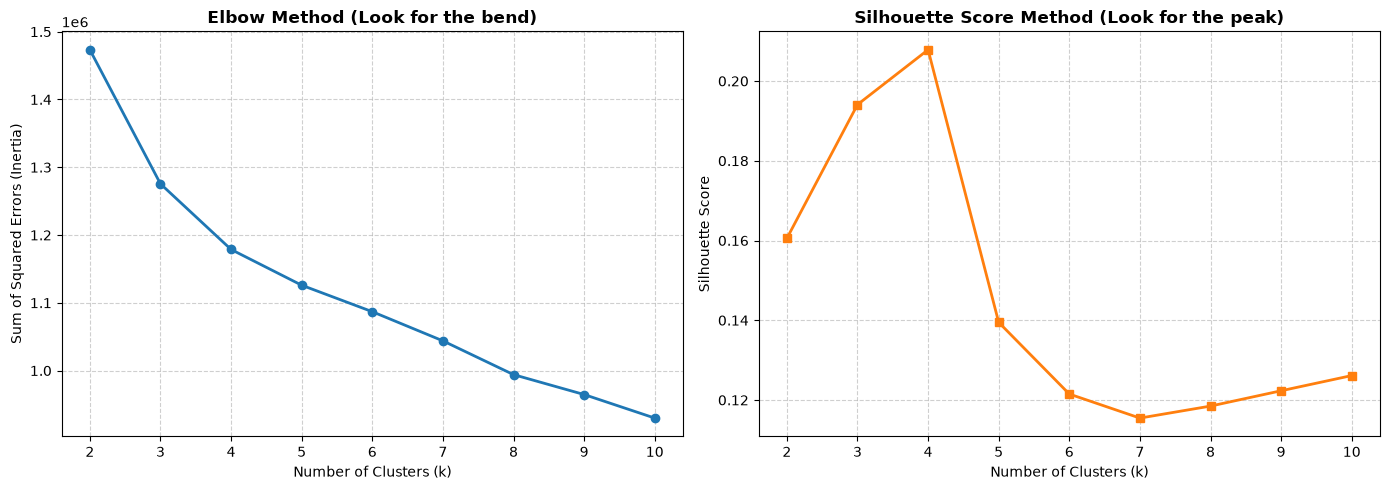

In [ ]:
import matplotlib.pyplot as plt
import pandas as pd
from sklearn.cluster import KMeans
from sklearn.metrics import silhouette_score
from sklearn.preprocessing import StandardScaler

file_path = r"C:\Users\pc\Desktop\miniproject4\single_genre_artists_dbscan_cleaned.xlsx"
df = pd.read_excel(file_path)

numerical_cols = df.select_dtypes(include=["int64", "float64"]).columns.tolist()
X = df[numerical_cols]

# ==============================================================================
# STEP 2: Standardise variables (mean=0, variance=1) so features with vast ranges 
# (e.g., danceability) are not affected.
# ==============================================================================

scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)

# ==============================================================================
# STEP 3: Using different values of k from range 2 to 11 to check which one is best using the elbow and silhouette score
# ==============================================================================

sse = []                
silhouette_scores = []  
k_range = range(2, 11)

for k in k_range:
    kmeans = KMeans(n_clusters=k, random_state=42, n_init="auto")
    kmeans.fit(X_scaled)

    sse.append(kmeans.inertia_)

    score = silhouette_score(X_scaled, kmeans.labels_)
    silhouette_scores.append(score)

# ==============================================================================
# STEP 4: Adding the elbow plot and silhouette plots for visualisation of best k value.
# ==============================================================================

plt.figure(figsize=(14, 5))

plt.subplot(1, 2, 1)
plt.plot(k_range, sse, marker="o", color="#1f77b4", linewidth=2)
plt.title("Elbow Method (Look for the bend)", fontsize=12, fontweight="bold")
plt.xlabel("Number of Clusters (k)")
plt.ylabel("Sum of Squared Errors (Inertia)")
plt.xticks(k_range)
plt.grid(True, linestyle="--", alpha=0.6)

plt.subplot(1, 2, 2)
plt.plot(k_range, silhouette_scores, marker="s", color="#ff7f0e", linewidth=2)
plt.title("Silhouette Score Method (Look for the peak)", fontsize=12, fontweight="bold")
plt.xlabel("Number of Clusters (k)")
plt.ylabel("Silhouette Score")
plt.xticks(k_range)
plt.grid(True, linestyle="--", alpha=0.6)

plt.tight_layout()
plt.show()

In [ ]:
Step 5: Dimensionality reduction using PCA to reduce the dataset to 2 components. 

In [ ]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.preprocessing import StandardScaler
from sklearn.decomposition import PCA
from sklearn.cluster import KMeans


file_path = r"C:\Users\pc\Desktop\miniproject4\single_genre_artists_dbscan_cleaned.xlsx"
df = pd.read_excel(file_path)

# Choosing the features for the Kmeans
audio_features = [
    'danceability', 'energy', 'loudness', 'speechiness', 
    'acousticness', 'instrumentalness', 'liveness', 
    'valence', 'tempo', 'duration_ms'
]
X_scaled = StandardScaler().fit_transform(df[audio_features])

# ==============================================================================
# STEP 2: k-mean value of 4 is taken as suggested above by elbow method and silhouette score
# ==============================================================================

optimal_k = 4 
kmeans = KMeans(n_clusters=optimal_k, random_state=42, n_init=10)
cluster_labels = kmeans.fit_predict(X_scaled)

# ==============================================================================
# STEP 3: dimensionality reduction to 2D with PCA method
# ==============================================================================

pca = PCA(n_components=2, random_state=42)
X_pca = pca.fit_transform(X_scaled)

plot_df = pd.DataFrame(X_pca, columns=['PCA Component 1', 'PCA Component 2'])
plot_df['Cluster'] = cluster_labels.astype(str)  

print(f"PCA 1 & 2 explain {sum(pca.explained_variance_ratio_)*100:.2f}% of the total data variance.")

# ==============================================================================
# STEP 4: 2D plot visualisation of the clusters after dimensionality reduction
# ==============================================================================

plt.figure(figsize=(10, 7))

sns.scatterplot(
    data=plot_df, 
    x='PCA Component 1', 
    y='PCA Component 2', 
    hue='Cluster', 
    palette='viridis',
    alpha=0.6,
    edgecolor='none'
)

plt.title('Amazon Music Clusters Visualized via PCA', fontsize=14, pad=15)
plt.xlabel('PCA Component 1', fontsize=12)
plt.ylabel('PCA Component 2', fontsize=12)
plt.grid(True, linestyle='--', alpha=0.5)
plt.legend(title='K-Means Cluster')

plt.tight_layout()
plt.show()

In [ ]:
Step 6: assigning the values to each of the clusters.

In [ ]:
import pandas as pd
from sklearn.cluster import KMeans
from sklearn.decomposition import PCA
from sklearn.preprocessing import StandardScaler

file_path = r"C:\Users\pc\Desktop\miniproject4\single_genre_artists_dbscan_cleaned.xlsx"
df = pd.read_excel(file_path)
print(f"Dataset successfully loaded! Total rows: {len(df)}")

# ==============================================================================
# STEP 2: isolate all the numeric columns needed and then apply the standard scaler
# ==============================================================================

numerical_cols = df.select_dtypes(include=["int64", "float64"]).columns
X_numerical = df[numerical_cols]

scaler = StandardScaler()
X_scaled = scaler.fit_transform(X_numerical)

# ==============================================================================
# STEP 3: making sure dimensionality is reduced to 2 pca. 
# ==============================================================================

pca = PCA(n_components=2, random_state=42)
X_pca = pca.fit_transform(X_scaled)
X_clustering = pd.DataFrame(
    data=X_pca,
    columns=["PCA_Component_1", "PCA_Component_2"],
)

# ==============================================================================
# STEP 4: here the k value of 4 is used for the clustering
# ==============================================================================
# Group the compressed 2D data points into 4 target profiles. Using k-means++ 
# ensures optimized initial centroid placement, minimizing total algorithm iterations.

optimal_k = 4
kmeans = KMeans(n_clusters=optimal_k, init="k-means++", random_state=42, n_init=10)

# Map the final cluster index labels directly back into the original dataset
df["Music_Cluster"] = kmeans.fit_predict(X_clustering)

# ==============================================================================
# STEP 5: exporting the clustered file with a new colum name as music cluster, assigning the songs to the clusters and displaying the clusters assigned. 
# ==============================================================================

df.to_excel("single_genre_artists_dbscan_cleaned.xlsx", index=False)

print("\n--- Process Complete ---")
print(f"Successfully assigned {len(df)} records into {optimal_k} clusters!")
print("The new column 'Music_Cluster' has been saved directly to your Excel file.")
print("\nSong distribution per cluster:")
print(df["Music_Cluster"].value_counts().sort_index())

Dataset successfully loaded! Total rows: 95628

--- Process Complete ---
Successfully assigned 95628 records into 4 clusters!
The new column 'Music_Cluster' has been saved directly to your Excel file.

Song distribution per cluster:
Music_Cluster
0    22452
1    48733
2    13346
3    11097
Name: count, dtype: int64


In [ ]:
Step 7: Cluster evaluation and interpretation. 

In [ ]:
import pandas as pd
from sklearn.cluster import KMeans
from sklearn.decomposition import PCA
from sklearn.metrics import davies_bouldin_score, silhouette_score
from sklearn.preprocessing import StandardScaler


file_path = r"C:\Users\pc\Desktop\miniproject4\single_genre_artists_dbscan_cleaned.xlsx"
df = pd.read_excel(file_path)

# using only the numeric columns for this
numerical_cols = df.select_dtypes(include=["int64", "float64"]).columns

# prior cluster results are removed to maintain evaluation integrity
if "Music_Cluster" in numerical_cols:
    numerical_cols = numerical_cols.drop("Music_Cluster")

X_numerical = df[numerical_cols]

# ==============================================================================
# STEP 2: Pca and standard scaler
# ==============================================================================

scaler = StandardScaler()
X_scaled = scaler.fit_transform(X_numerical)

pca = PCA(n_components=2, random_state=42)
X_pca = pca.fit_transform(X_scaled)

# ==============================================================================
# STEP 3: k-means step to make sure it is evaluated on the correct k value of 4.
# ==============================================================================

optimal_k = 4
kmeans = KMeans(n_clusters=optimal_k, init="k-means++", random_state=42, n_init=10)
labels = kmeans.fit_predict(X_pca)

# ==============================================================================
# STEP 4: Here i am using the silhouette score and davies bouldin score and inertia for checking how well the songs values fit into the clusters.
# ==============================================================================
sil_score = silhouette_score(X_pca, labels)

db_index = davies_bouldin_score(X_pca, labels)

inertia_val = kmeans.inertia_

# Printing my evaluation values for each one to check.
print("=========================================")
print("     CLUSTER EVALUATION METRICS          ")
print("=========================================")
print(f"Silhouette Score (Higher is better)      : {sil_score:.4f}")
print(f"Davies-Bouldin Index (Lower is better)  : {db_index:.4f}")
print(f"Inertia / Compactness (Lower is better) : {inertia_val:.2f}")
print("=========================================\n")

# ==============================================================================
# STEP 5: Grouping all the 10 audio features and assigning to the relevant cluster
# ==============================================================================
core_audio_features = [
    "danceability",
    "energy",
    "loudness",
    "speechiness",
    "acousticness",
    "instrumentalness",
    "liveness",
    "valence",
    "tempo",
    "duration_ms"
]

available_features = [col for col in core_audio_features if col in df.columns]

cluster_profiles = (
    df.groupby("Music_Cluster")[available_features].mean().round(3)
)

print("=========================================")
print("      MUSIC CLUSTER PROFILES (MEANS)     ")
print("=========================================")
print(cluster_profiles.to_string())
print("=========================================")

     CLUSTER EVALUATION METRICS          
Silhouette Score (Higher is better)      : 0.3901
Davies-Bouldin Index (Lower is better)  : 0.8225
Inertia / Compactness (Lower is better) : 130239.64

      MUSIC CLUSTER PROFILES (MEANS)     
               danceability  energy  loudness  speechiness  acousticness  instrumentalness  liveness  valence    tempo  duration_ms
Music_Cluster                                                                                                                      
0                     0.523   0.401   -11.034        0.067         0.640             0.097     0.190    0.471  117.274   230860.850
1                     0.633   0.702    -7.486        0.073         0.254             0.045     0.197    0.677  125.245   225152.605
2                     0.662   0.484   -12.646        0.754         0.554             0.002     0.418    0.576  101.391    98260.789
3                     0.424   0.186   -17.108        0.091         0.881             0.309     0.186    

In [ ]:
Step 8: Visualisations to show how songs are clustered. 

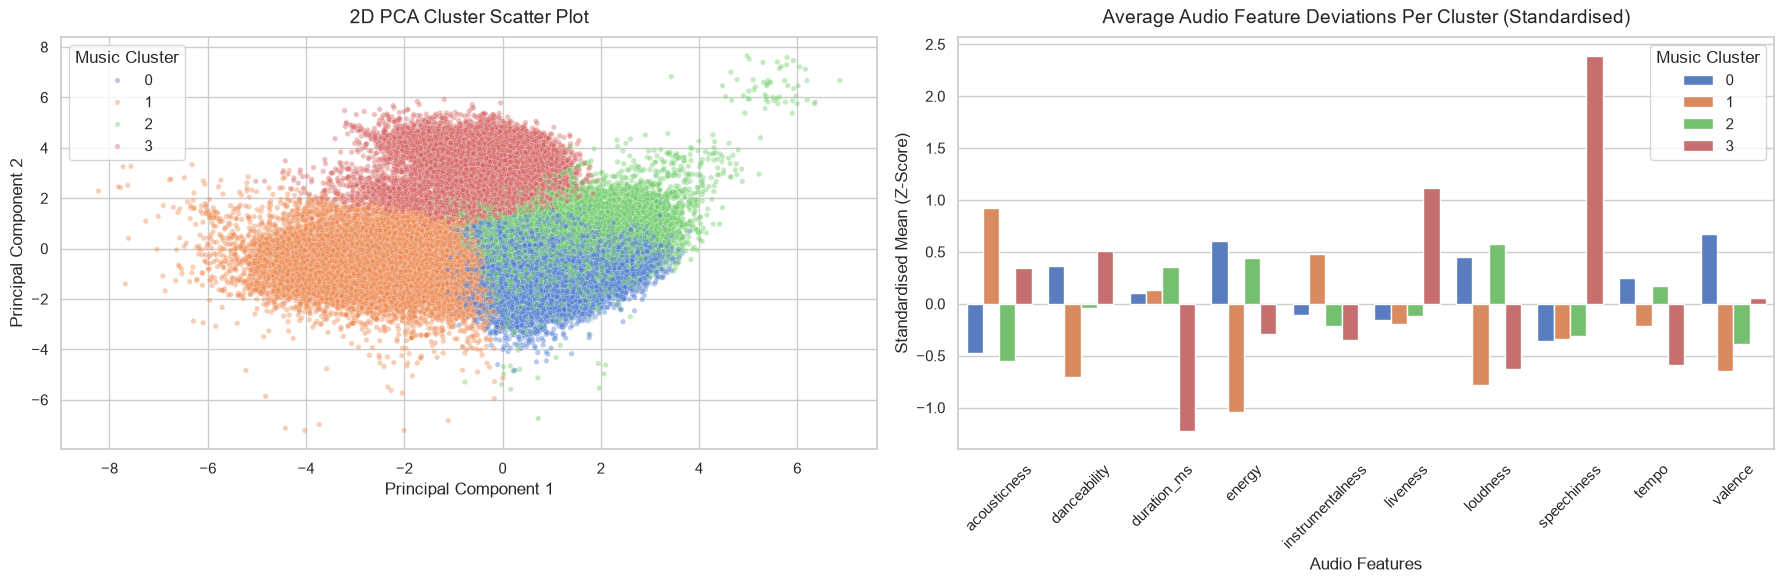

C:\Users\pc\AppData\Local\Temp\ipykernel_3660\4110239365.py:115: UserWarning: Ignoring `palette` because no `hue` variable has been assigned.
  sns.kdeplot(
C:\Users\pc\AppData\Local\Temp\ipykernel_3660\4110239365.py:115: UserWarning: Ignoring `palette` because no `hue` variable has been assigned.
  sns.kdeplot(
C:\Users\pc\AppData\Local\Temp\ipykernel_3660\4110239365.py:115: UserWarning: Ignoring `palette` because no `hue` variable has been assigned.
  sns.kdeplot(
C:\Users\pc\AppData\Local\Temp\ipykernel_3660\4110239365.py:115: UserWarning: Ignoring `palette` because no `hue` variable has been assigned.
  sns.kdeplot(


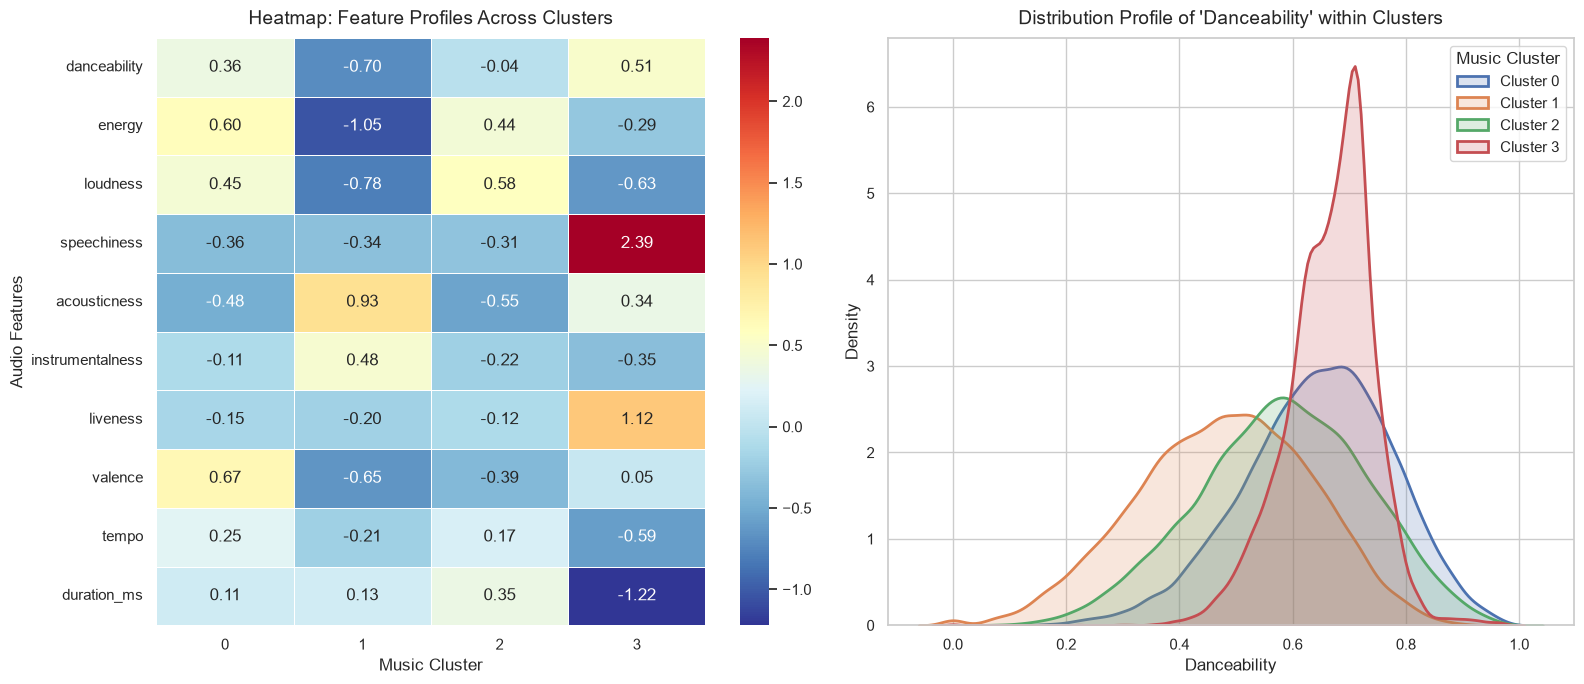

In [ ]:
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import seaborn as sns
from sklearn.cluster import KMeans
from sklearn.decomposition import PCA
from sklearn.preprocessing import StandardScaler

file_path = r"C:\Users\pc\Desktop\miniproject4\single_genre_artists_dbscan_cleaned.xlsx"
df = pd.read_excel(file_path)

# making sure only numerical columns are used and correct PCA and k means value is used for this analysis
numerical_cols = df.select_dtypes(include=["int64", "float64"]).columns
if "Music_Cluster" in numerical_cols:
    numerical_cols = numerical_cols.drop("Music_Cluster")

X_numerical = df[numerical_cols]

scaler = StandardScaler()
X_scaled = scaler.fit_transform(X_numerical)
df_scaled = pd.DataFrame(X_scaled, columns=numerical_cols)

pca = PCA(n_components=2, random_state=42)
X_pca = pca.fit_transform(X_scaled)

optimal_k = 4
kmeans = KMeans(n_clusters=optimal_k, init="k-means++", random_state=42, n_init=10)
df["Music_Cluster"] = kmeans.fit_predict(X_pca)
df_scaled["Music_Cluster"] = df["Music_Cluster"]

audio_features = [
    "danceability",
    "energy",
    "loudness",
    "speechiness",
    "acousticness",
    "instrumentalness",
    "liveness",
    "valence",
    "tempo",
    "duration_ms"
]
available_features = [col for col in audio_features if col in df_scaled.columns]


sns.set_theme(style="whitegrid")
cluster_palette = sns.color_palette("muted", n_colors=optimal_k)

# ==============================================================================
# making a scatter plot to see how the clusters are showing
# ==============================================================================

fig, axes = plt.subplots(1, 2, figsize=(18, 6))

sns.scatterplot(
    x=X_pca[:, 0],
    y=X_pca[:, 1],
    hue=df["Music_Cluster"],
    palette=cluster_palette,
    alpha=0.4,
    s=15,
    ax=axes[0],
)
axes[0].set_title("2D PCA Cluster Scatter Plot", fontsize=14, pad=10)
axes[0].set_xlabel("Principal Component 1", fontsize=12)
axes[0].set_ylabel("Principal Component 2", fontsize=12)
axes[0].legend(title="Music Cluster", loc="best")

df_melted = df_scaled.melt(
    id_vars=["Music_Cluster"],
    value_vars=available_features,
    var_name="Audio Feature",
    value_name="Mean Scaled Value",
)
df_grouped_bar = (
    df_melted.groupby(["Music_Cluster", "Audio Feature"])["Mean Scaled Value"]
    .mean()
    .reset_index()
)

# making a bar plot to check for distributions of the clusters and its values
sns.barplot(
    data=df_grouped_bar,
    x="Audio Feature",
    y="Mean Scaled Value",
    hue="Music_Cluster",
    palette=cluster_palette,
    ax=axes[1],
)
axes[1].set_title("Average Audio Feature Deviations Per Cluster (Standardised)", fontsize=14, pad=10)
axes[1].set_xlabel("Audio Features", fontsize=12)
axes[1].set_ylabel("Standardised Mean (Z-Score)", fontsize=12) 
axes[1].tick_params(axis="x", rotation=45)                     
axes[1].legend(title="Music Cluster", loc="best")

plt.tight_layout()
plt.show()

# ==============================================================================
# making a heatmap to check for analysis
# ==============================================================================

fig, axes = plt.subplots(1, 2, figsize=(16, 7))

cluster_means_scaled = df_scaled.groupby("Music_Cluster")[available_features].mean().T

sns.heatmap(
    cluster_means_scaled,
    annot=True,
    cmap="RdYlBu_r",
    fmt=".2f",
    cbar=True,
    linewidths=0.5,
    ax=axes[0],
)
axes[0].set_title("Heatmap: Feature Profiles Across Clusters", fontsize=14, pad=10)
axes[0].set_xlabel("Music Cluster", fontsize=12)
axes[0].set_ylabel("Audio Features", fontsize=12)

# making a KDE plot for analysis
target_dist_feature = "danceability"
if target_dist_feature in df.columns:
    for cluster_id in sorted(df["Music_Cluster"].unique()):
        
        cluster_data = df[df["Music_Cluster"] == cluster_id][target_dist_feature]
        sns.kdeplot(
            cluster_data,
            label=f"Cluster {cluster_id}",
            fill=True,
            alpha=0.2,
            ax=axes[1],
            linewidth=2,
            palette=cluster_palette if cluster_id < len(cluster_palette) else None
        )
    axes[1].set_title(
        f"Distribution Profile of '{target_dist_feature.capitalize()}' within Clusters",
        fontsize=14,
        pad=10,
    )
    axes[1].set_xlabel(target_dist_feature.capitalize(), fontsize=12)
    axes[1].set_ylabel("Density", fontsize=12)
    axes[1].legend(title="Music Cluster")

plt.tight_layout()
plt.show()

In [ ]:
Step 8: Final analysis and export of the dataset. 

In [ ]:
import pandas as pd
from sklearn.cluster import KMeans
from sklearn.decomposition import PCA
from sklearn.preprocessing import StandardScaler

file_path = r"C:\Users\pc\Desktop\miniproject4\single_genre_artists_dbscan_cleaned.xlsx"
df = pd.read_excel(file_path)

# after loading the dataset the numerical columns are used, standard scaler method, k-means and pca method applied for this analysis
numerical_cols = df.select_dtypes(include=["int64", "float64"]).columns
if "Music_Cluster" in numerical_cols:
    numerical_cols = numerical_cols.drop("Music_Cluster")

X_numerical = df[numerical_cols]

scaler = StandardScaler()
X_scaled = scaler.fit_transform(X_numerical)

optimal_k = 4
kmeans = KMeans(n_clusters=optimal_k, init="k-means++", random_state=42, n_init=10)
df["Music_Cluster"] = kmeans.fit_predict(X_scaled) 

pca = PCA(n_components=2, random_state=42)
X_pca = pca.fit_transform(X_scaled)

# ==============================================================================
# exporting the clustered file with the cluster labels added 
# ==============================================================================

output_csv_path = r"C:\Users\pc\Desktop\miniproject4\clustered_music_dataset.csv"
df.to_csv(output_csv_path, index=False)
print(f"Success: Exported complete clustered dataset to: {output_csv_path}")

# ==============================================================================
# filtering clusters to find the top 5 songs for each cluster 0,1,2,3
# ==============================================================================

print("\n=======================================================")
print("          TOP 5 MOST POPULAR TRACKS PER CLUSTER        ")
print("=======================================================")

display_cols = ["name_song", "name_artists", "popularity_songs"]

missing_cols = [col for col in display_cols if col not in df.columns]
if missing_cols:
    print(f" Warning: The following expected columns were missing: {missing_cols}")
    print("Available columns in your file are:", df.columns.tolist())

available_display = [col for col in display_cols if col in df.columns]

sort_column = "popularity_songs" if "popularity_songs" in df.columns else available_display[-1]

for cluster_id in sorted(df["Music_Cluster"].unique()):
    print(f"\n--- MUSIC CLUSTER {cluster_id} ---")
    cluster_df = df[df["Music_Cluster"] == cluster_id]
    
    if not cluster_df.empty and available_display:
        cluster_top_tracks = cluster_df.sort_values(by=sort_column, ascending=False).head(5)
        print(cluster_top_tracks[available_display].to_string(index=False))
    else:
        print("No tracks found or no matching display columns available.")
print("=======================================================")

Success: Exported complete clustered dataset to: C:\Users\pc\Desktop\miniproject4\clustered_music_dataset.csv

          TOP 5 MOST POPULAR TRACKS PER CLUSTER        

--- MUSIC CLUSTER 0 ---
                    name_song       name_artists  popularity_songs
Shot For Me - Spotify Singles      The Kid LAROI                73
            Graveto - Ao Vivo MarÃ­lia MendonÃ§a                71
        The Chicken Wing Beat      Ricky Desktop                70
                         Mark            Shahmen                67
                   NICHT WACH            Luciano                66

--- MUSIC CLUSTER 1 ---
 name_song    name_artists  popularity_songs
    Arcade Duncan Laurence                89
    Arcade Duncan Laurence                83
    YKWIM?        Yot Club                79
Blue Jeans          GANGGA                79
   Bertaut    Nadin Amizah                78

--- MUSIC CLUSTER 2 ---
              name_song  name_artists  popularity_songs
            WITHOUT YOU The Ki